## Система рекомендаций игр Steam (Content-Based)

In [1]:
import json
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Загрузка данных

In [2]:
with open('../data/steamUsersDataset.json', encoding='utf-8') as file:
    steamUsersDataset = json.load(file)

filteredSteamUsersDataset = []
for user in steamUsersDataset:
    if not user.get('error'):
        filteredSteamUsersDataset.append(user)

print(f"Публичных пользователей: {len(filteredSteamUsersDataset)}")

with open('../data/steamGamesDataset.json', encoding='utf-8') as file:
    steamGamesDataset = json.load(file)

print(f"Игр для рекомендаций: {len(steamGamesDataset)}")

Публичных пользователей: 20390
Игр для рекомендаций: 33233


### Подготовка тегов

In [3]:
gameToNormalizedTags = {}

for game in steamGamesDataset:
    appId = game.get('appid')
    rawTags = game.get('tags', {})
    if not rawTags:
        gameToNormalizedTags[appId] = {}
        continue
    totalWeight = sum(rawTags.values())
    if totalWeight == 0:
        gameToNormalizedTags[appId] = {}
        continue
    normalized = {tag: weight / totalWeight for tag, weight in rawTags.items()}
    gameToNormalizedTags[appId] = normalized
    
print("Маппинг appid → нормализованные теги создан")

Маппинг appid → нормализованные теги создан


### Построение user-tag матрицы

In [4]:
tagsNum = 200

allTagCounter = Counter()
for tags in gameToNormalizedTags.values():
    for tag in tags:
        allTagCounter[tag] += 1

topTags = [tag for tag, _ in allTagCounter.most_common(tagsNum)]
print(f"Используем {len(topTags)} топ-тегов")

userTagFeaturesList = []

for user in filteredSteamUsersDataset:
    steamId = user.get('steamId')
    tagVector = {tag: 0.0 for tag in topTags}
    totalPlaytimeHours = 0.0
    
    for game in user.get('ownedGames', []):
        appId = game.get('appid')
        playtimeMinutes = game.get('playtimeForever', 0)
        playtimeHours = playtimeMinutes / 60.0
        if playtimeHours <= 0:
            continue
        totalPlaytimeHours += playtimeHours
        normalizedTags = gameToNormalizedTags.get(appId, {})
        for tag, normWeight in normalizedTags.items():
            if tag in topTags:
                tagVector[tag] += playtimeHours * normWeight
    
    if totalPlaytimeHours > 0:
        tagVector = {tag: value / totalPlaytimeHours for tag, value in tagVector.items()}
    
    userTagFeaturesList.append({'steamId': steamId, **tagVector})

userTagFeaturesDataFrame = pd.DataFrame(userTagFeaturesList)
print("User-tag матрица построена. Размер:", userTagFeaturesDataFrame.shape)

Используем 200 топ-тегов
User-tag матрица построена. Размер: (20390, 201)


### Построение game-tag матрицы

In [5]:
gameTagList = []

for game in steamGamesDataset:
    appId = game.get('appid')
    name = game.get('name')
    normalizedTags = gameToNormalizedTags.get(appId, {})
    if not normalizedTags:
        continue
    row = {'appid': appId, 'name': name}
    for tag in topTags:
        row[tag] = normalizedTags.get(tag, 0.0)
    gameTagList.append(row)

gameTagDataFrame = pd.DataFrame(gameTagList)

print("Game-tag матрица построена. Размер:", gameTagDataFrame.shape)

Game-tag матрица построена. Размер: (28595, 202)


### Функция рекомендаций

In [6]:
def recommendGamesForUser(steamId: str, topN: int = 10):
    """
    Рекомендует topN игр пользователю по cosine similarity тегов.
    """

    if steamId not in userTagFeaturesDataFrame['steamId'].values:
        print(f"Пользователь {steamId} не найден.")
        return pd.DataFrame()
    
    userRow = userTagFeaturesDataFrame[userTagFeaturesDataFrame['steamId'] == steamId].iloc[0]
    userVector = userRow[topTags].values.reshape(1, -1)
    
    gameVectors = gameTagDataFrame[topTags].values
    
    similarities = cosine_similarity(userVector, gameVectors)[0]
    
    recommendations = gameTagDataFrame.copy()
    recommendations['similarityScore'] = similarities
    
    userOwnedAppIds = set()
    for userData in filteredSteamUsersDataset:
        if userData.get('steamId') == steamId:
            userOwnedAppIds = {g['appid'] for g in userData.get('ownedGames', [])}
            break
    
    recommendations = recommendations[~recommendations['appid'].isin(userOwnedAppIds)]
    
    topRecommendations = recommendations.nlargest(topN, 'similarityScore')
    return topRecommendations[['appid', 'name', 'similarityScore']]

### Пример рекомендаций

Пример рекомендаций для пользователя 76561198392691910
         appid                     name  similarityScore
8024   2617700              Tinkerlands         0.694834
2064    538100            Feel The Snow         0.686933
14382   676500             Time Warpers         0.675049
1035    298110                Far Cry 4         0.670064
4824    342480                 Gunscape         0.666187
2066    539470           Police Stories         0.664638
254      34870  Sniper: Ghost Warrior 2         0.663746
1188    326410                 Windward         0.663365
26274   764580               RealmCraft         0.659557
6351    307880             Savage Lands         0.658319


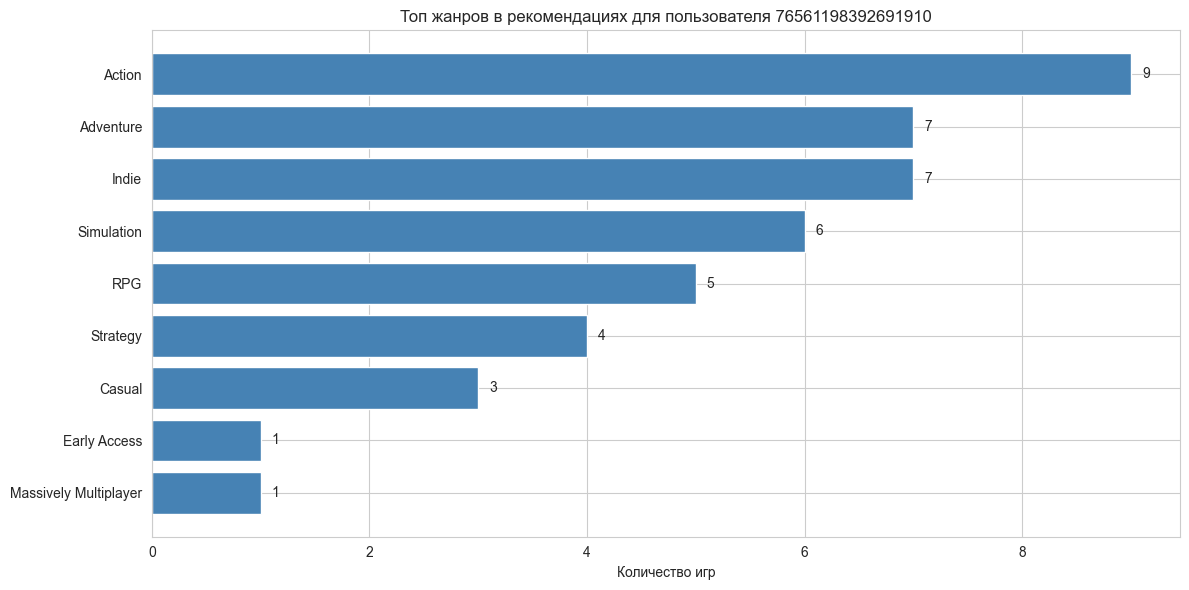

In [7]:
exampleSteamId = filteredSteamUsersDataset[4]['steamId']
print(f"Пример рекомендаций для пользователя {exampleSteamId}")
recs = recommendGamesForUser(exampleSteamId, topN=10)
print(recs)

topRecAppIds = recs['appid'].values
genreCounter = Counter()

for appId in topRecAppIds:
    for game in steamGamesDataset:
        if game.get('appid') == appId:
            genreStr = game.get('genre', '')
            if genreStr:
                genres = [g.strip() for g in genreStr.split(',')]
                for genre in genres:
                    if genre:
                        genreCounter[genre] += 1
            break

if genreCounter:
    topGenres = genreCounter.most_common(10)
    genreNames = [g[0] for g in topGenres]
    genreCounts = [g[1] for g in topGenres]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(range(len(genreNames)), genreCounts, color='steelblue')
    ax.set_yticks(range(len(genreNames)))
    ax.set_yticklabels(genreNames)
    ax.set_xlabel('Количество игр')
    ax.set_title(f'Топ жанров в рекомендациях для пользователя {exampleSteamId}')
    ax.invert_yaxis()
    
    for i, (bar, count) in enumerate(zip(bars, genreCounts)):
        ax.text(count + 0.1, i, str(count), va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных о жанрах для визуализации")

### Оценка качества (Hold-out validation)

In [8]:
# Метрики качества: Precision@K, Recall@K
def evaluateRecommendations(k: int = 10, minGames: int = 20, evaluationPercentage: float = 0.1):
    """
    - Для пользователей с >= minGames играми
    - evaluationPercentage: процент пользователей с наибольшим количеством игр (0.0-1.0)
    - Скрываем 20% игр как test set
    - Строим user-vector только на train-играх
    - Считаем, сколько test-игр попало в топ-K рекомендаций
    """
    precisionList = []
    recallList = []
    
    eligibleUsers = [
        user for user in filteredSteamUsersDataset
        if len(user.get('ownedGames', [])) >= minGames
    ]
    
    eligibleUsers.sort(key=lambda u: len(u.get('ownedGames', [])), reverse=True)
    
    evaluationCount = int(len(eligibleUsers) * evaluationPercentage)
    usersToEvaluate = eligibleUsers[:evaluationCount]
    
    for user in usersToEvaluate:
        steamId = user.get('steamId')
        ownedGames = user.get('ownedGames', [])
        
        ownedGamesSorted = sorted(ownedGames, key=lambda g: g.get('playtimeForever', 0), reverse=True)
        trainSize = int(len(ownedGamesSorted) * 0.8)
        trainGames = ownedGamesSorted[:trainSize]
        testGames = ownedGamesSorted[trainSize:]
        
        testAppIds = {g['appid'] for g in testGames}
        
        tagVector = {tag: 0.0 for tag in topTags}
        totalTrainHours = 0.0
        
        for game in trainGames:
            appId = game['appid']
            playtimeHours = game.get('playtimeForever', 0) / 60.0
            if playtimeHours <= 0:
                continue
            totalTrainHours += playtimeHours
            normTags = gameToNormalizedTags.get(appId, {})
            for tag, weight in normTags.items():
                if tag in topTags:
                    tagVector[tag] += playtimeHours * weight
        
        if totalTrainHours == 0:
            continue
        userVector = np.array([tagVector[tag] / totalTrainHours for tag in topTags]).reshape(1, -1)
        
        gameVectors = gameTagDataFrame[topTags].values
        similarities = cosine_similarity(userVector, gameVectors)[0]
        
        trainAppIds = {g['appid'] for g in trainGames}
        recDf = gameTagDataFrame.copy()
        recDf['score'] = similarities
        recDf = recDf[~recDf['appid'].isin(trainAppIds)]
        
        topK = recDf.nlargest(k, 'score')['appid'].values
        
        hits = len(set(topK) & testAppIds)
        precision = hits / k
        recall = hits / len(testAppIds) if len(testAppIds) > 0 else 0
        
        precisionList.append(precision)
        recallList.append(recall)
    
    meanPrecision = np.mean(precisionList)
    meanRecall = np.mean(recallList)
    
    print(f"Оценка на {len(precisionList)} пользователях (топ {evaluationPercentage*100:.0f}% с наибольшим количеством игр, min {minGames})")
    print(f"Precision@{k}: {meanPrecision:.4f}")
    print(f"Recall@{k}:    {meanRecall:.4f}")
    
    return meanPrecision, meanRecall

In [9]:
evaluateRecommendations(k=10, minGames=20)

Оценка на 1301 пользователях (топ 10% с наибольшим количеством игр, min 20)
Precision@10: 0.0173
Recall@10:    0.0022


(np.float64(0.017294388931591083), np.float64(0.0021913481419925025))

### Сохранение модели (user и game векторы)

In [10]:
userTagFeaturesDataFrame.to_csv('../data/userTagMatrix.csv', index=False)
gameTagDataFrame.to_csv('../data/gameTagMatrix.csv', index=False)

print("Матрицы сохранены для дальнейшего использования.")

Матрицы сохранены для дальнейшего использования.


## Collaborative Filtering (User-Based)

In [11]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

userItemData = []

allAppIds = set()
for user in filteredSteamUsersDataset:
    for game in user.get('ownedGames', []):
        allAppIds.add(game['appid'])

allAppIdsList = sorted(list(allAppIds))
appIdToIndex = {appId: idx for idx, appId in enumerate(allAppIdsList)}
steamIdToIndex = {user['steamId']: idx for idx, user in enumerate(filteredSteamUsersDataset)}

print(f"Построение user-item матрицы: {len(filteredSteamUsersDataset)} пользователей * {len(allAppIdsList)} игр")

rows = []
cols = []
data = []

for userIdx, user in enumerate(filteredSteamUsersDataset):
    for game in user.get('ownedGames', []):
        appId = game['appid']
        playtimeHours = game.get('playtimeForever', 0) / 60.0
        if appId in appIdToIndex:
            rows.append(userIdx)
            cols.append(appIdToIndex[appId])
            data.append(1 + np.log1p(playtimeHours))

userItemMatrix = csr_matrix((data, (rows, cols)), shape=(len(filteredSteamUsersDataset), len(allAppIdsList)))
print(f"User-item матрица построена. Размер: {userItemMatrix.shape}, ненулевых элементов: {userItemMatrix.nnz}")

Построение user-item матрицы: 20390 пользователей * 33233 игр
User-item матрица построена. Размер: (20390, 33233), ненулевых элементов: 1711559


### Обучение KNN модели для поиска похожих пользователей

In [12]:
knnModel = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20)
knnModel.fit(userItemMatrix)

print("KNN модель обучена для поиска похожих пользователей")

KNN модель обучена для поиска похожих пользователей


### Функция рекомендаций на основе похожих пользователей

In [13]:
def recommendGamesCollaborative(steamId: str, topN: int = 10, numNeighbors: int = 10):
    """
    Рекомендует игры на основе похожих пользователей (User-Based CF).
    """
    
    if steamId not in steamIdToIndex:
        print(f"Пользователь {steamId} не найден.")
        return pd.DataFrame()
    
    userIdx = steamIdToIndex[steamId]
    userVector = userItemMatrix[userIdx]
    
    distances, indices = knnModel.kneighbors(userVector, n_neighbors=numNeighbors + 1)
    
    # Исключаем самого пользователя (первый результат)
    similarUserIndices = indices.flatten()[1:]
    similarUserDistances = distances.flatten()[1:]
    
    userOwnedAppIds = set()
    for user in filteredSteamUsersDataset:
        if user['steamId'] == steamId:
            userOwnedAppIds = {g['appid'] for g in user.get('ownedGames', [])}
            break
    
    gameScores = {}
    
    for neighborIdx, distance in zip(similarUserIndices, similarUserDistances):
        similarity = 1 - distance
        neighborUser = filteredSteamUsersDataset[neighborIdx]
        
        for game in neighborUser.get('ownedGames', []):
            appId = game['appid']
            if appId not in userOwnedAppIds:
                playtimeHours = game.get('playtimeForever', 0) / 60.0
                score = similarity * (1 + np.log1p(playtimeHours))
                gameScores[appId] = gameScores.get(appId, 0) + score
    
    topGames = sorted(gameScores.items(), key=lambda x: x[1], reverse=True)[:topN]
    
    recommendations = []
    for appId, score in topGames:
        gameName = "Unknown"
        for game in steamGamesDataset:
            if game.get('appid') == appId:
                gameName = game.get('name', 'Unknown')
                break
        recommendations.append({
            'appid': appId,
            'name': gameName,
            'collaborativeScore': score
        })
    
    return pd.DataFrame(recommendations)

### Пример collaborative рекомендаций

In [14]:
print(f"Collaborative рекомендации для пользователя {exampleSteamId}")
collabRecs = recommendGamesCollaborative(exampleSteamId, topN=10, numNeighbors=15)
print(collabRecs)

Collaborative рекомендации для пользователя 76561198392691910
    appid                           name  collaborativeScore
0    4000                    Garry's Mod           22.061003
1  367520                  Hollow Knight           20.816927
2  250900  The Binding of Isaac: Rebirth           18.334313
3  381210               Dead by Daylight           18.329156
4  629520                       Soundpad           18.290927
5  632360                 Risk of Rain 2           17.823568
6  588650                     Dead Cells           17.117690
7  646570                 Slay the Spire           15.183116
8  394360              Hearts of Iron IV           14.714099
9  322170                  Geometry Dash           14.700987


### Оценка качества Collaborative Filtering

In [15]:
def evaluateCollaborativeFiltering(k: int = 10, minGames: int = 20, numNeighbors: int = 15, evaluationPercentage: float = 0.1):
    """
    Оценка Collaborative Filtering методом hold-out validation.
    evaluationPercentage: процент пользователей с наибольшим количеством игр (0.0-1.0)
    """
    precisionList = []
    recallList = []
    
    eligibleUsers = [
        user for user in filteredSteamUsersDataset
        if len(user.get('ownedGames', [])) >= minGames and user.get('steamId') in steamIdToIndex
    ]
    
    eligibleUsers.sort(key=lambda u: len(u.get('ownedGames', [])), reverse=True)
    
    evaluationCount = int(len(eligibleUsers) * evaluationPercentage)
    usersToEvaluate = eligibleUsers[:evaluationCount]
    
    for user in usersToEvaluate:
        steamId = user.get('steamId')
        ownedGames = user.get('ownedGames', [])
        
        ownedGamesSorted = sorted(ownedGames, key=lambda g: g.get('playtimeForever', 0), reverse=True)
        trainSize = int(len(ownedGamesSorted) * 0.8)
        trainGames = ownedGamesSorted[:trainSize]
        testGames = ownedGamesSorted[trainSize:]
        
        testAppIds = {g['appid'] for g in testGames}
        trainAppIds = {g['appid'] for g in trainGames}
        
        userIdx = steamIdToIndex[steamId]
        tempUserVector = userItemMatrix[userIdx].toarray().flatten()
        
        for appId in testAppIds:
            if appId in appIdToIndex:
                tempUserVector[appIdToIndex[appId]] = 0
        
        tempUserVector = csr_matrix(tempUserVector)
        
        distances, indices = knnModel.kneighbors(tempUserVector, n_neighbors=numNeighbors + 1)
        similarUserIndices = indices.flatten()[1:]
        similarUserDistances = distances.flatten()[1:]
        
        gameScores = {}
        for neighborIdx, distance in zip(similarUserIndices, similarUserDistances):
            similarity = 1 - distance
            neighborUser = filteredSteamUsersDataset[neighborIdx]
            
            for game in neighborUser.get('ownedGames', []):
                appId = game['appid']
                if appId not in trainAppIds:
                    playtimeHours = game.get('playtimeForever', 0) / 60.0
                    score = similarity * (1 + np.log1p(playtimeHours))
                    gameScores[appId] = gameScores.get(appId, 0) + score
        
        if not gameScores:
            continue
        
        topK = sorted(gameScores.items(), key=lambda x: x[1], reverse=True)[:k]
        topKAppIds = {appId for appId, _ in topK}
        
        hits = len(topKAppIds & testAppIds)
        precision = hits / k
        recall = hits / len(testAppIds) if len(testAppIds) > 0 else 0
        
        precisionList.append(precision)
        recallList.append(recall)
    
    meanPrecision = np.mean(precisionList)
    meanRecall = np.mean(recallList)
    
    print(f"Collaborative Filtering оценка на {len(precisionList)} пользователях (топ {evaluationPercentage*100:.0f}% с наибольшим количеством игр, min {minGames})")
    print(f"Precision@{k}: {meanPrecision:.4f}")
    print(f"Recall@{k}:    {meanRecall:.4f}")
    
    return meanPrecision, meanRecall

In [16]:
evaluateCollaborativeFiltering(k=10, minGames=20, numNeighbors=15)

Collaborative Filtering оценка на 1400 пользователях (топ 10% с наибольшим количеством игр, min 20)
Precision@10: 0.0689
Recall@10:    0.0097


(np.float64(0.06892857142857142), np.float64(0.009656930908782117))

## Гибридная модель (Content-Based + Collaborative Filtering)

In [17]:
def recommendGamesHybrid(steamId: str, topN: int = 10, numNeighbors: int = 15, contentWeight: float = 0.3, collaborativeWeight: float = 0.7):
    if steamId not in userTagFeaturesDataFrame['steamId'].values:
        print(f"Пользователь {steamId} не найден в content-based данных.")
        return pd.DataFrame()
    if steamId not in steamIdToIndex:
        print(f"Пользователь {steamId} не найден в collaborative данных.")
        return pd.DataFrame()
    
    userOwnedAppIds = set()
    for user in filteredSteamUsersDataset:
        if user['steamId'] == steamId:
            userOwnedAppIds = {g['appid'] for g in user.get('ownedGames', [])}
            break
    
    userRow = userTagFeaturesDataFrame[userTagFeaturesDataFrame['steamId'] == steamId].iloc[0]
    userVector = userRow[topTags].values.reshape(1, -1)
    gameVectors = gameTagDataFrame[topTags].values
    contentSimilarities = cosine_similarity(userVector, gameVectors)[0]
    
    contentScoresDict = {}
    for idx, appId in enumerate(gameTagDataFrame['appid'].values):
        if appId not in userOwnedAppIds:
            contentScoresDict[appId] = contentSimilarities[idx]
    
    userIdx = steamIdToIndex[steamId]
    userItemVector = userItemMatrix[userIdx]
    distances, indices = knnModel.kneighbors(userItemVector, n_neighbors=numNeighbors + 1)
    
    similarUserIndices = indices.flatten()[1:]
    similarUserDistances = distances.flatten()[1:]
    
    collaborativeScoresDict = {}
    for neighborIdx, distance in zip(similarUserIndices, similarUserDistances):
        similarity = 1 - distance
        neighborUser = filteredSteamUsersDataset[neighborIdx]
        for game in neighborUser.get('ownedGames', []):
            appId = game['appid']
            if appId not in userOwnedAppIds:
                playtimeHours = game.get('playtimeForever', 0) / 60.0
                score = similarity * (1 + np.log1p(playtimeHours))
                collaborativeScoresDict[appId] = collaborativeScoresDict.get(appId, 0) + score
    
    if contentScoresDict:
        maxContentScore = max(contentScoresDict.values())
        minContentScore = min(contentScoresDict.values())
        if maxContentScore > minContentScore:
            contentScoresDict = {appId: (score - minContentScore) / (maxContentScore - minContentScore) for appId, score in contentScoresDict.items()}
    
    if collaborativeScoresDict:
        maxCollabScore = max(collaborativeScoresDict.values())
        minCollabScore = min(collaborativeScoresDict.values())
        if maxCollabScore > minCollabScore:
            collaborativeScoresDict = {appId: (score - minCollabScore) / (maxCollabScore - minCollabScore) for appId, score in collaborativeScoresDict.items()}
    
    allAppIds = set(contentScoresDict.keys()) | set(collaborativeScoresDict.keys())
    hybridScores = {}
    for appId in allAppIds:
        contentScore = contentScoresDict.get(appId, 0.0)
        collaborativeScore = collaborativeScoresDict.get(appId, 0.0)
        hybridScores[appId] = contentWeight * contentScore + collaborativeWeight * collaborativeScore
    
    topGames = sorted(hybridScores.items(), key=lambda x: x[1], reverse=True)[:topN]
    recommendations = []
    for appId, hybridScore in topGames:
        gameName = "Unknown"
        for game in steamGamesDataset:
            if game.get('appid') == appId:
                gameName = game.get('name', 'Unknown')
                break
        recommendations.append({'appid': appId, 'name': gameName, 'hybridScore': hybridScore, 'contentScore': contentScoresDict.get(appId, 0.0), 'collaborativeScore': collaborativeScoresDict.get(appId, 0.0)})
    return pd.DataFrame(recommendations)

### Пример гибридных рекомендаций

In [18]:
print(f"Гибридные рекомендации для пользователя {exampleSteamId}")
print("Веса: Content-Based = 0.3, Collaborative = 0.7\n")
hybridRecs = recommendGamesHybrid(exampleSteamId, topN=10, numNeighbors=15, contentWeight=0.3, collaborativeWeight=0.7)
print(hybridRecs)

Гибридные рекомендации для пользователя 76561198392691910
Веса: Content-Based = 0.3, Collaborative = 0.7

    appid                           name  hybridScore  contentScore  \
0    4000                    Garry's Mod     0.959947      0.866491   
1  367520                  Hollow Knight     0.873991      0.713385   
2  632360                 Risk of Rain 2     0.780740      0.723554   
3  250900  The Binding of Isaac: Rebirth     0.774643      0.648460   
4  588650                     Dead Cells     0.755267      0.714343   
5  381210               Dead by Daylight     0.726639      0.488997   
6  304930                       Unturned     0.676023      0.848734   
7  427520                       Factorio     0.669182      0.756044   
8  700330         SCP: Secret Laboratory     0.638442      0.746568   
9  394360              Hearts of Iron IV     0.635380      0.572478   

   collaborativeScore  
0            1.000000  
1            0.942823  
2            0.805248  
3            0.8

### Оценка качества гибридной модели

In [19]:
def evaluateHybridModel(k=10, minGames=20, numNeighbors=15, contentWeight=0.3, collaborativeWeight=0.7, evaluationPercentage=0.1):
    precisionList, recallList = [], []
    eligibleUsers = [u for u in filteredSteamUsersDataset if len(u.get('ownedGames', [])) >= minGames and u.get('steamId') in steamIdToIndex and u.get('steamId') in userTagFeaturesDataFrame['steamId'].values]
    eligibleUsers.sort(key=lambda u: len(u.get('ownedGames', [])), reverse=True)
    usersToEvaluate = eligibleUsers[:int(len(eligibleUsers) * evaluationPercentage)]
    
    for user in usersToEvaluate:
        steamId, ownedGames = user.get('steamId'), user.get('ownedGames', [])
        ownedGamesSorted = sorted(ownedGames, key=lambda g: g.get('playtimeForever', 0), reverse=True)
        trainSize = int(len(ownedGamesSorted) * 0.8)
        trainGames, testGames = ownedGamesSorted[:trainSize], ownedGamesSorted[trainSize:]
        testAppIds, trainAppIds = {g['appid'] for g in testGames}, {g['appid'] for g in trainGames}
        
        tagVector, totalTrainHours = {tag: 0.0 for tag in topTags}, 0.0
        for game in trainGames:
            appId, playtimeHours = game['appid'], game.get('playtimeForever', 0) / 60.0
            if playtimeHours <= 0: continue
            totalTrainHours += playtimeHours
            for tag, weight in gameToNormalizedTags.get(appId, {}).items():
                if tag in topTags: tagVector[tag] += playtimeHours * weight
        
        if totalTrainHours == 0: continue
        userVector = np.array([tagVector[tag] / totalTrainHours for tag in topTags]).reshape(1, -1)
        contentSimilarities = cosine_similarity(userVector, gameTagDataFrame[topTags].values)[0]
        contentScoresDict = {appId: contentSimilarities[idx] for idx, appId in enumerate(gameTagDataFrame['appid'].values) if appId not in trainAppIds}
        
        userIdx = steamIdToIndex[steamId]
        tempUserVector = userItemMatrix[userIdx].toarray().flatten()
        for appId in testAppIds:
            if appId in appIdToIndex: tempUserVector[appIdToIndex[appId]] = 0
        tempUserVector = csr_matrix(tempUserVector)
        distances, indices = knnModel.kneighbors(tempUserVector, n_neighbors=numNeighbors + 1)
        
        collaborativeScoresDict = {}
        for neighborIdx, distance in zip(indices.flatten()[1:], distances.flatten()[1:]):
            similarity = 1 - distance
            for game in filteredSteamUsersDataset[neighborIdx].get('ownedGames', []):
                appId = game['appid']
                if appId not in trainAppIds:
                    score = similarity * (1 + np.log1p(game.get('playtimeForever', 0) / 60.0))
                    collaborativeScoresDict[appId] = collaborativeScoresDict.get(appId, 0) + score
        
        if contentScoresDict:
            maxC, minC = max(contentScoresDict.values()), min(contentScoresDict.values())
            if maxC > minC: contentScoresDict = {a: (s - minC) / (maxC - minC) for a, s in contentScoresDict.items()}
        if collaborativeScoresDict:
            maxC, minC = max(collaborativeScoresDict.values()), min(collaborativeScoresDict.values())
            if maxC > minC: collaborativeScoresDict = {a: (s - minC) / (maxC - minC) for a, s in collaborativeScoresDict.items()}
        
        allAppIds = set(contentScoresDict.keys()) | set(collaborativeScoresDict.keys())
        hybridScores = {a: contentWeight * contentScoresDict.get(a, 0.0) + collaborativeWeight * collaborativeScoresDict.get(a, 0.0) for a in allAppIds}
        if not hybridScores: continue
        
        topK = sorted(hybridScores.items(), key=lambda x: x[1], reverse=True)[:k]
        topKAppIds = {appId for appId, _ in topK}
        hits = len(topKAppIds & testAppIds)
        precisionList.append(hits / k)
        recallList.append(hits / len(testAppIds) if len(testAppIds) > 0 else 0)
    
    meanPrecision, meanRecall = np.mean(precisionList), np.mean(recallList)
    print(f"Гибридная модель: {len(precisionList)} пользователей, Precision@{k}: {meanPrecision:.4f}, Recall@{k}: {meanRecall:.4f}")
    return meanPrecision, meanRecall

In [20]:
evaluateHybridModel(k=10, minGames=20, numNeighbors=15, contentWeight=0.3, collaborativeWeight=0.7)

Гибридная модель: 1301 пользователей, Precision@10: 0.0676, Recall@10: 0.0095


(np.float64(0.06756341275941584), np.float64(0.00951309797011867))